# Advanced Analytics + Risk Metrics

In [5]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("data/raw/02_nav_history.csv")

print("Shape:", nav_df.shape)

print("\nColumns:")
print(nav_df.columns.tolist())

nav_df.head()

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
# Make sure dates are treated as dates
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort by fund and date
nav_df = nav_df.sort_values(["amfi_code", "date"]).copy()

# Calculate daily return for each fund
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df[["amfi_code", "date", "nav", "daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


## 1. Historical VaR and CVaR

Historical Value at Risk (VaR) at the 95% confidence level is calculated using the 5th percentile of daily returns. Conditional Value at Risk (CVaR) is calculated as the mean of returns below the VaR threshold.

In [7]:
def calculate_var_cvar(group):
    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    return pd.Series({
        "observations": len(returns),
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })


var_cvar_report = (
    nav_df.groupby("amfi_code")
    .apply(calculate_var_cvar)
    .reset_index()
)

print("Number of schemes:", len(var_cvar_report))

var_cvar_report.head(10)

Number of schemes: 40


,amfi_code,observations,VaR_95,CVaR_95
0,100016,1149.0,-0.014364,-0.018060
1,100025,1149.0,-0.003793,-0.004994
2,100033,1149.0,-0.019034,-0.023456
3,101206,1149.0,-0.013282,-0.017439
4,101207,1149.0,-0.026021,-0.032459
5,101208,1149.0,-0.000269,-0.000422
6,102885,1149.0,-0.012613,-0.015490
7,102886,1149.0,-0.019220,-0.023251
8,102887,1149.0,-0.015232,-0.019411
9,118632,1149.0,-0.013954,-0.017619


In [8]:
print(var_cvar_report.shape)
print(var_cvar_report["amfi_code"].nunique())
print(var_cvar_report.isna().sum())

(40, 4)
40
amfi_code       0
observations    0
VaR_95          0
CVaR_95         0
dtype: int64


In [9]:
# Save VaR and CVaR results
output_path = "var_cvar_report.csv"

var_cvar_report.to_csv(output_path, index=False)

print(f"Saved successfully: {output_path}")

Saved successfully: var_cvar_report.csv


In [10]:
from pathlib import Path

report_file = Path("var_cvar_report.csv")

print("Exists:", report_file.exists())
print("Location:", report_file.resolve())
print("\nPreview:")
print(pd.read_csv(report_file).head())

Exists: True
Location: D:\Mutual-Fund-Analytics\var_cvar_report.csv

Preview:
   amfi_code  observations    VaR_95   CVaR_95
0     100016        1149.0 -0.014364 -0.018060
1     100025        1149.0 -0.003793 -0.004994
2     100033        1149.0 -0.019034 -0.023456
3     101206        1149.0 -0.013282 -0.017439
4     101207        1149.0 -0.026021 -0.032459


## 2. Rolling 90-Day Sharpe Ratio

The 90-day rolling Sharpe ratio measures risk-adjusted performance over a moving 90-day window and is annualized using the square root of 252 trading days.

In [11]:
# 5 key funds for rolling Sharpe analysis
key_funds = {
    119551: "SBI Bluechip",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

rolling_sharpe = nav_df[nav_df["amfi_code"].isin(key_funds.keys())].copy()

# Calculate 90-day rolling Sharpe ratio
rolling_sharpe["rolling_sharpe_90"] = (
    rolling_sharpe.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            / x.rolling(90).std()
            * np.sqrt(252)
        )
    )
)

rolling_sharpe["fund_name"] = rolling_sharpe["amfi_code"].map(key_funds)

print("Funds:", rolling_sharpe["fund_name"].unique())
print("Rows:", len(rolling_sharpe))

rolling_sharpe[
    ["date", "amfi_code", "fund_name", "rolling_sharpe_90"]
].tail(10)

Funds: <StringArray>
['Nippon Large Cap',    'Axis Bluechip',     'SBI Bluechip',
   'ICICI Bluechip',   'Kotak Bluechip']
Length: 5, dtype: str
Rows: 5750


,date,amfi_code,fund_name,rolling_sharpe_90
24140,2026-05-18,120841,Kotak Bluechip,1.743906
24141,2026-05-19,120841,Kotak Bluechip,1.902434
24142,2026-05-20,120841,Kotak Bluechip,2.035416
24143,2026-05-21,120841,Kotak Bluechip,2.141182
24144,2026-05-22,120841,Kotak Bluechip,2.148822
24145,2026-05-25,120841,Kotak Bluechip,2.427230
24146,2026-05-26,120841,Kotak Bluechip,2.355138
24147,2026-05-27,120841,Kotak Bluechip,2.240101
24148,2026-05-28,120841,Kotak Bluechip,2.324704
24149,2026-05-29,120841,Kotak Bluechip,2.167518


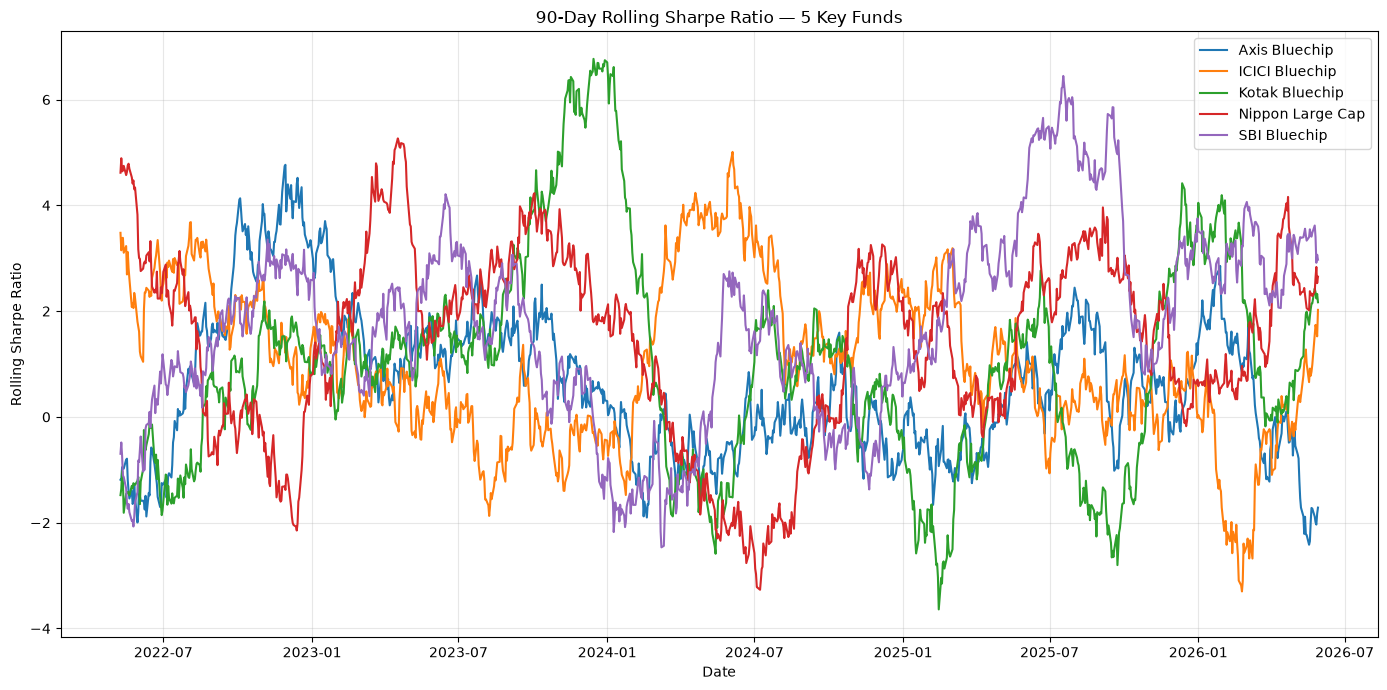

In [12]:
import matplotlib.pyplot as plt
# Remove rows where the 90-day rolling Sharpe is not available
chart_data = rolling_sharpe.dropna(
    subset=["rolling_sharpe_90"]
).copy()

# Create the chart
plt.figure(figsize=(14, 7))

for fund_name, group in chart_data.groupby("fund_name"):
    plt.plot(
        group["date"],
        group["rolling_sharpe_90"],
        label=fund_name
    )

plt.title("90-Day Rolling Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the required deliverable
plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
from pathlib import Path

chart_file = Path("rolling_sharpe_chart.png")

print("Exists:", chart_file.exists())
print("Location:", chart_file.resolve())

Exists: True
Location: D:\Mutual-Fund-Analytics\rolling_sharpe_chart.png


In [14]:
transactions_df = pd.read_csv(
    "data/raw/08_investor_transactions.csv"
)

print("Shape:", transactions_df.shape)
print("\nColumns:")
print(transactions_df.columns.tolist())

transactions_df.head()

Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


## 3. Investor Cohort Analysis

Investors are grouped according to the year of their first transaction. Each cohort is analyzed using average SIP amount, total invested amount, and top fund preference.

In [15]:
# Convert transaction date to datetime
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"]
)

# Sort transactions chronologically for each investor
transactions_df = transactions_df.sort_values(
    ["investor_id", "transaction_date"]
).copy()

# Find each investor's first transaction date
first_transaction = (
    transactions_df
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index(name="first_transaction_date")
)

# Extract the first transaction year
first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"].dt.year
)

print(first_transaction.head())
print("\nNumber of investors:", len(first_transaction))
print("\nCohort years:")
print(sorted(first_transaction["cohort_year"].unique()))

  investor_id first_transaction_date  cohort_year
0   INV000001             2024-11-04         2024
1   INV000002             2024-03-29         2024
2   INV000003             2024-07-16         2024
3   INV000004             2024-03-16         2024
4   INV000005             2024-04-27         2024

Number of investors: 5000

Cohort years:
[np.int32(2024), np.int32(2025)]


In [16]:
# Add cohort year to every transaction
transactions_cohort = transactions_df.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

print(
    transactions_cohort[
        ["investor_id", "transaction_date", "cohort_year"]
    ].head(10)
)

  investor_id transaction_date  cohort_year
0   INV000001       2024-11-04         2024
1   INV000001       2025-01-14         2024
2   INV000001       2025-01-19         2024
3   INV000002       2024-03-29         2024
4   INV000002       2024-07-14         2024
5   INV000002       2024-09-21         2024
6   INV000002       2024-10-03         2024
7   INV000002       2025-01-23         2024
8   INV000002       2025-05-17         2024
9   INV000003       2024-07-16         2024


In [17]:
# Average SIP amount by investor cohort
avg_sip_by_cohort = (
    transactions_cohort[
        transactions_cohort["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount_inr")
)

avg_sip_by_cohort

,cohort_year,avg_sip_amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [18]:
# Total invested by cohort
investment_transactions = transactions_cohort[
    transactions_cohort["transaction_type"].isin(["SIP", "Lumpsum"])
]

total_invested_by_cohort = (
    investment_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

total_invested_by_cohort

,cohort_year,total_invested_inr
0,2024,2258062304
1,2025,18992635


In [19]:
# Count transactions by cohort and fund
fund_counts = (
    transactions_cohort
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

# Find the most preferred fund in each cohort
top_fund_by_cohort = (
    fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    .reset_index(drop=True)
)

top_fund_by_cohort

,cohort_year,amfi_code,transaction_count
0,2024,148568,874
1,2025,119599,12


In [20]:
# Combine cohort metrics
cohort_analysis = (
    avg_sip_by_cohort
    .merge(
        total_invested_by_cohort,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_fund_by_cohort[
            ["cohort_year", "amfi_code", "transaction_count"]
        ],
        on="cohort_year",
        how="outer"
    )
)

cohort_analysis

,cohort_year,avg_sip_amount_inr,total_invested_inr,amfi_code,transaction_count
0,2024,10996.885825,2258062304,148568,874
1,2025,13505.209581,18992635,119599,12


In [21]:
fund_master = pd.read_csv(
    "data/raw/01_fund_master.csv"
)

print("Columns:")
print(fund_master.columns.tolist())

fund_master.head()

Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [22]:
# Keep only the columns needed to map AMFI code to scheme name
fund_lookup = fund_master[
    ["amfi_code", "scheme_name"]
].drop_duplicates("amfi_code")

# Add scheme name to the cohort analysis
cohort_analysis = cohort_analysis.merge(
    fund_lookup,
    on="amfi_code",
    how="left"
)

# Arrange the columns neatly
cohort_analysis = cohort_analysis[
    [
        "cohort_year",
        "avg_sip_amount_inr",
        "total_invested_inr",
        "amfi_code",
        "scheme_name",
        "transaction_count"
    ]
]

cohort_analysis

,cohort_year,avg_sip_amount_inr,total_invested_inr,amfi_code,scheme_name,transaction_count
0,2024,10996.885825,2258062304,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,119599,SBI Small Cap Fund - Direct Plan - Growth,12


## 4. SIP Continuity Analysis

SIP continuity is analyzed for investors who have made at least 6 SIP transactions. The average gap between consecutive SIP transaction dates is calculated for each eligible investor. Investors with an average gap greater than 35 days are flagged as **at-risk**.

In [24]:
# Keep only SIP transactions
sip_df = transactions_cohort[
    transactions_cohort["transaction_type"] == "SIP"
].copy()

# Sort by investor and transaction date
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

print("Total SIP transactions:", len(sip_df))
print("Unique SIP investors:", sip_df["investor_id"].nunique())

Total SIP transactions: 19716
Unique SIP investors: 4762


In [25]:
# Calculate gap in days between consecutive SIP transactions
sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_df[
    ["investor_id", "transaction_date", "gap_days"]
].head(15)

,investor_id,transaction_date,gap_days
0,INV000001,2024-11-04,NaN
2,INV000001,2025-01-19,76.0
3,INV000002,2024-03-29,NaN
5,INV000002,2024-09-21,176.0
8,INV000002,2025-05-17,238.0
9,INV000003,2024-07-16,NaN
10,INV000003,2025-03-11,238.0
11,INV000004,2024-03-16,NaN
13,INV000004,2024-04-11,26.0
16,INV000004,2024-05-09,28.0


In [26]:
# Count SIP transactions for each investor
sip_counts = (
    sip_df.groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

# Investors eligible for continuity analysis
eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
]["investor_id"]

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

Investors with 6+ SIP transactions: 1362


In [27]:
# Keep only investors with 6 or more SIP transactions
sip_eligible = sip_df[
    sip_df["investor_id"].isin(eligible_investors)
].copy()

# Calculate average gap between SIP transactions for each investor
sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_transaction_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

# Flag investors whose average gap is greater than 35 days
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "at-risk",
    "regular"
)

sip_continuity.head(10)

,investor_id,sip_transaction_count,avg_gap_days,status
0,INV000004,6,85.400000,at-risk
1,INV000008,6,70.400000,at-risk
2,INV000010,6,64.800000,at-risk
3,INV000011,7,40.166667,at-risk
4,INV000012,8,57.000000,at-risk
5,INV000013,7,55.333333,at-risk
6,INV000014,7,75.333333,at-risk
7,INV000023,8,58.571429,at-risk
8,INV000028,6,93.600000,at-risk
9,INV000029,7,60.666667,at-risk


In [28]:
print("Eligible investors:", len(sip_continuity))

print("\nStatus counts:")
print(sip_continuity["status"].value_counts())

print("\nAverage gap statistics:")
print(sip_continuity["avg_gap_days"].describe())

Eligible investors: 1362

Status counts:
status
at-risk    1332
regular      30
Name: count, dtype: int64

Average gap statistics:
count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: avg_gap_days, dtype: float64


In [29]:
continuity_rate = (
    (sip_continuity["status"] == "regular").mean() * 100
)

at_risk_rate = (
    (sip_continuity["status"] == "at-risk").mean() * 100
)

print(f"SIP continuity rate: {continuity_rate:.2f}%")
print(f"At-risk rate: {at_risk_rate:.2f}%")

SIP continuity rate: 2.20%
At-risk rate: 97.80%


In [30]:
# Save SIP continuity analysis for future reference
sip_continuity.to_csv(
    "sip_continuity_analysis.csv",
    index=False
)

print("Saved:", Path("sip_continuity_analysis.csv").resolve())

Saved: D:\Mutual-Fund-Analytics\sip_continuity_analysis.csv


## 5. Simple Fund Recommender

A simple fund recommender is created based on investor risk appetite. The user can select **Low**, **Moderate**, or **High** risk appetite, and the system returns the top 3 funds ranked by Sharpe ratio within the corresponding risk category.

In [31]:
scheme_perf = pd.read_csv(
    "data/raw/07_scheme_performance.csv"
)

print("Shape:", scheme_perf.shape)
print("\nColumns:")
print(scheme_perf.columns.tolist())

Shape: (40, 19)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [32]:
print("Risk grades:")
print(scheme_perf["risk_grade"].value_counts())

print("\nUnique risk grades:")
print(scheme_perf["risk_grade"].unique())

Risk grades:
risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

Unique risk grades:
<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


In [33]:
# See the funds that will be considered for High risk appetite
high_risk_funds = scheme_perf[
    scheme_perf["risk_grade"].isin(
        ["High", "Moderately High", "Very High"]
    )
].sort_values("sharpe_ratio", ascending=False)

high_risk_funds[
    ["scheme_name", "risk_grade", "sharpe_ratio"]
]

,scheme_name,risk_grade,sharpe_ratio
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,0.98
13,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.98
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
33,UTI Flexi Cap Fund - Regular - Growth,Moderately High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately High,0.91
29,ABSL Small Cap Fund - Regular - Growth,Very High,0.90
38,DSP Midcap Fund - Regular - Growth,High,0.90


## 6. Sector HHI Concentration

The Herfindahl-Hirschman Index (HHI) is used to measure portfolio concentration across sectors. HHI is calculated as the sum of squared sector weights. Higher HHI values indicate greater portfolio concentration.

In [39]:
portfolio_df = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

print("Shape:", portfolio_df.shape)

print("\nColumns:")
print(portfolio_df.columns.tolist())

portfolio_df.head()

Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [40]:
# Calculate sector weights for each fund
sector_weights = (
    portfolio_df
    .groupby(["amfi_code", "sector"], as_index=False)["weight_pct"]
    .sum()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [41]:
# Convert percentage weights to proportions
sector_weights["weight"] = sector_weights["weight_pct"] / 100

# Calculate HHI for each fund
hhi_df = (
    sector_weights
    .assign(weight_squared=sector_weights["weight"] ** 2)
    .groupby("amfi_code", as_index=False)["weight_squared"]
    .sum()
    .rename(columns={"weight_squared": "HHI"})
)

# Convert to the commonly used 0–10,000 HHI scale
hhi_df["HHI_10000"] = hhi_df["HHI"] * 10000

hhi_df = hhi_df.sort_values(
    "HHI_10000",
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI,HHI_10000
11,119092,0.296769,2967.6909
30,148569,0.254992,2549.9194
27,125498,0.253155,2531.5500
6,102887,0.251383,2513.8255
32,149323,0.241077,2410.7664
21,120505,0.238695,2386.9504
10,118635,0.237497,2374.9677
18,119599,0.232361,2323.6120
22,120506,0.231464,2314.6434
1,100033,0.227647,2276.4744


In [42]:
fund_master = pd.read_csv(
    "data/raw/01_fund_master.csv"
)

equity_hhi = hhi_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category", "sub_category"]
    ],
    on="amfi_code",
    how="left"
)

equity_hhi = equity_hhi[
    equity_hhi["category"].str.lower().eq("equity")
].sort_values(
    "HHI_10000",
    ascending=False
)

equity_hhi[
    [
        "amfi_code",
        "scheme_name",
        "sub_category",
        "HHI_10000"
    ]
].head(10)

,amfi_code,scheme_name,sub_category,HHI_10000
0,119092,Axis Bluechip Fund - Regular - Growth,Large Cap,2967.6909
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,2549.9194
2,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,2531.5500
3,102887,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap,2513.8255
4,149323,DSP Midcap Fund - Regular - Growth,Mid Cap,2410.7664
5,120505,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,2386.9504
6,118635,Nippon India ETF Nifty 50 BeES,Index/ETF,2374.9677
7,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,2323.6120
8,120506,ICICI Pru Value Discovery Fund - Regular - Growth,Value,2314.6434
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,2276.4744


## HHI Interpretation

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration across sectors. A higher HHI indicates that a fund's portfolio is more concentrated in fewer sectors, while a lower HHI indicates greater sector diversification.

Among the analyzed equity funds, Axis Bluechip Fund - Regular - Growth has the highest HHI of 2967.69, indicating the highest sector concentration in the observed portfolio data. Mirae Asset Tax Saver Fund and HDFC Mid-Cap Opportunities Fund - Direct also show relatively high concentration levels.

In [43]:
# Save HHI results for all equity funds
equity_hhi.to_csv(
    "reports/equity_fund_hhi.csv",
    index=False
)

print("HHI report saved successfully.")
print("Rows:", len(equity_hhi))

HHI report saved successfully.
Rows: 34


## 7. Advanced Insights

### Insight 1 — Highest Portfolio Risk

The historical VaR and CVaR analysis shows that downside risk varies across the 40 analyzed schemes. VaR at the 95% confidence level identifies the 5th percentile of daily returns, while CVaR measures the average return during observations below the VaR threshold. These metrics help identify funds with comparatively higher downside exposure.

### Insight 2 — Rolling Sharpe Performance

The 90-day rolling Sharpe analysis shows that risk-adjusted performance changes over time across the five key funds: Nippon Large Cap, Axis Bluechip, SBI Bluechip, ICICI Bluechip, and Kotak Bluechip. The rolling measure highlights periods when a fund generated stronger or weaker returns relative to its volatility.

### Insight 3 — Investor Cohort Behaviour

The investor cohort analysis shows differences between investors entering in 2024 and 2025. The 2024 cohort recorded an average SIP amount of ₹10,996.89 and total invested amount of ₹2,258,062,304, while the 2025 cohort recorded an average SIP amount of ₹13,505.21 and total invested amount of ₹18,992,635. The analysis also identifies the preferred fund for each cohort based on transaction activity.

### Insight 4 — SIP Continuity and At-Risk Investors

Among 4,762 unique SIP investors, 1,362 investors had at least six SIP transactions and were eligible for continuity analysis. Of these eligible investors, 1,332 were classified as **at-risk** because their average SIP gap exceeded 35 days, while only 30 were classified as regular. This resulted in a SIP continuity rate of **2.20%** and an at-risk rate of **97.80%**, indicating a significant potential investor-retention concern.

### Insight 5 — Portfolio Concentration

The sector HHI analysis shows meaningful differences in portfolio concentration across equity funds. Axis Bluechip Fund - Regular - Growth recorded the highest HHI of **2967.69** among the analyzed funds, followed by Mirae Asset Tax Saver Fund - Regular - Growth at **2549.92** and HDFC Mid-Cap Opportunities Fund - Direct - Growth at **2531.55**. Higher HHI values indicate greater concentration across sectors and therefore comparatively lower sector diversification.


In [ ]:
# Make sure dates are treated as dates
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort by fund and date
nav_df = nav_df.sort_values(["amfi_code", "date"]).copy()

# Calculate daily return for each fund
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df[["amfi_code", "date", "nav", "daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073
